🎯 ACCURACY SUR LE TEST SET : 1.0000 (100.00%)


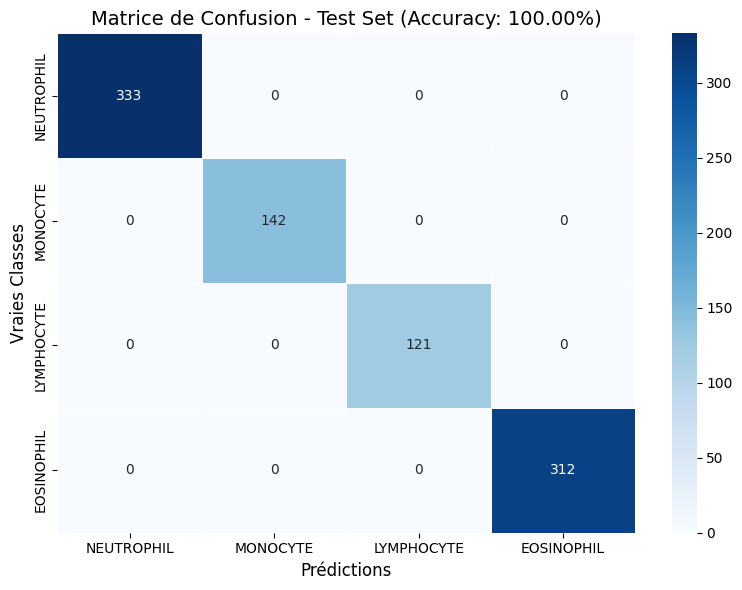


📊 PERFORMANCE PAR CLASSE :
--------------------------------------------------
  NEUTROPHIL : Precision=1.000 | Recall=1.000 | F1-Score=1.000
    MONOCYTE : Precision=1.000 | Recall=1.000 | F1-Score=1.000
  LYMPHOCYTE : Precision=1.000 | Recall=1.000 | F1-Score=1.000
  EOSINOPHIL : Precision=1.000 | Recall=1.000 | F1-Score=1.000
--------------------------------------------------


In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("..")
RESULTS_JSON = PROJECT_ROOT / "outputs" / "reports" / "test_results.json"

if not RESULTS_JSON.exists():
    print(f"[WARNING] Fichier de résultats introuvable : {RESULTS_JSON}")
    print("[INFO] Veuillez d'abord exécuter scripts/09_evaluate_test_set.py")
else:
    
    with open(RESULTS_JSON, 'r') as f:
        results = json.load(f)
    
    accuracy = results['test_accuracy']
    class_names = results['class_names']
    conf_matrix = np.array(results['confusion_matrix'])
    
    
    print("=" * 50)
    print(f"🎯 ACCURACY SUR LE TEST SET : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("=" * 50)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True, linewidths=0.5)
    plt.title(f'Matrice de Confusion - Test Set (Accuracy: {accuracy*100:.2f}%)', fontsize=14)
    plt.xlabel('Prédictions', fontsize=12)
    plt.ylabel('Vraies Classes', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    
    print("\n📊 PERFORMANCE PAR CLASSE :")
    print("-" * 50)
    for class_name in class_names:
        metrics = results['classification_report'][class_name]
        print(f"{class_name:>12} : Precision={metrics['precision']:.3f} | Recall={metrics['recall']:.3f} | F1-Score={metrics['f1-score']:.3f}")
    print("-" * 50)
    
    
    f1_scores = [results['classification_report'][c]['f1-score'] for c in class_names]
    min_idx = np.argmin(f1_scores)
    
    
    
    max_idx = np.argmax(f1_scores)
    